# 06 — Blended Ensemble & Final Submission

**Competition:** A Cloned Airbnb Booking Prediction Competition — K353  
**Course:** COMP 468 — Abdullah Gül University

## Goal
Combine the **out-of-fold (OOF) predictions** of all models we built so far into a single blended prediction that beats any individual model.

All component models use **identical CV splits** (`KFold(5, shuffle=True, random_state=42)`), so blending the OOFs is statistically sound.

Blending strategy:
1. **Equal-weight average** — sanity baseline.
2. **Weight optimisation on OOF** — find weights `w_i ≥ 0, sum=1` that minimise OOF MSE (`scipy.optimize.minimize` with SLSQP).

Both options are simple **weighted averaging** (no out-of-course stacking).

Outputs:
- `outputs/submission_blend.csv` ← **final submission**
- `outputs/blend_weights.json`

## 1. Setup & Load OOFs / Submissions

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
OUT_DIR = Path('../outputs')
DATA_DIR = Path('../data')
print('OUT_DIR =', OUT_DIR.resolve())

OUT_DIR = C:\pprojelerim\Airbnb-K353\outputs


In [2]:
# Load target (for OOF MSE) and the test IDs
train_y  = pd.read_csv(DATA_DIR / 'reserve_2016Q3_train.csv')
test_ids = pd.read_csv(DATA_DIR / 'PropertyID_test.csv')['PropertyID'].values
y = train_y['NumReserveDays2016Q3'].astype(float).values
n = len(y)
print(f'Train rows: {n} | Test rows: {len(test_ids)}')

Train rows: 24372 | Test rows: 24318


In [3]:
# Pick whichever OOFs are present on disk. Missing ones are simply skipped.
candidates = {
    'DecisionTree'    : 'oof_DecisionTree.npy',
    'RandomForest'    : 'oof_RandomForest.npy',
    'GradientBoosting': 'oof_GradientBoosting.npy',
    'XGBoost'         : 'oof_XGBoost.npy',
    'MLP'             : 'oof_MLP.npy',
}
oofs = {}
for name, fname in candidates.items():
    p = OUT_DIR / fname
    if p.exists():
        oofs[name] = np.load(p)
        mse = mean_squared_error(y, np.clip(oofs[name], 0, 92))
        print(f'{name:18s} loaded | OOF MSE = {mse:.3f}')
    else:
        print(f'{name:18s} MISSING ({fname})')
assert len(oofs) >= 2, 'Need at least two OOFs to blend.'

DecisionTree       loaded | OOF MSE = 239.539
RandomForest       loaded | OOF MSE = 196.231
GradientBoosting   loaded | OOF MSE = 183.790
XGBoost            loaded | OOF MSE = 222.773
MLP                loaded | OOF MSE = 215.651


In [4]:
# Matching test submissions for each model
sub_paths = {
    'DecisionTree'    : 'submission_baseline_DecisionTree.csv',
    'RandomForest'    : 'submission_baseline_RandomForest.csv',
    'GradientBoosting': 'submission_baseline_GradientBoosting.csv',
    'XGBoost'         : 'submission_xgboost.csv',
    'MLP'             : 'submission_mlp.csv',
}
test_preds = {}
for name, fname in sub_paths.items():
    p = OUT_DIR / fname
    if name in oofs and p.exists():
        df = pd.read_csv(p)
        assert (df['Property[Q3]_test'].values == test_ids).all(), f'ID mismatch in {fname}'
        test_preds[name] = df['Pred'].values
        print(f'{name:18s} test preds loaded ({len(df)})')
model_names = list(oofs.keys())
model_names = [m for m in model_names if m in test_preds]
print('\nModels in blend:', model_names)

DecisionTree       test preds loaded (24318)
RandomForest       test preds loaded (24318)
GradientBoosting   test preds loaded (24318)
XGBoost            test preds loaded (24318)
MLP                test preds loaded (24318)

Models in blend: ['DecisionTree', 'RandomForest', 'GradientBoosting', 'XGBoost', 'MLP']


## 2. OOF Correlations
Diverse models (low pairwise correlation) blend better than similar ones.

In [5]:
oof_matrix = np.column_stack([np.clip(oofs[m], 0, 92) for m in model_names])
corr = pd.DataFrame(oof_matrix, columns=model_names).corr()
print('OOF correlation matrix:')
print(corr.round(3))

OOF correlation matrix:
                  DecisionTree  RandomForest  GradientBoosting  XGBoost    MLP
DecisionTree             1.000         0.949             0.951    0.925  0.922
RandomForest             0.949         1.000             0.986    0.960  0.959
GradientBoosting         0.951         0.986             1.000    0.972  0.968
XGBoost                  0.925         0.960             0.972    1.000  0.972
MLP                      0.922         0.959             0.968    0.972  1.000


## 3. Equal-Weight Average (baseline blend)

In [6]:
blend_equal = np.clip(oof_matrix.mean(axis=1), 0, 92)
mse_equal = mean_squared_error(y, blend_equal)
print(f'Equal-weight blend OOF MSE = {mse_equal:.3f}')
print(f'(best single model      = {min(mean_squared_error(y, oof_matrix[:, i]) for i in range(len(model_names))):.3f})')

Equal-weight blend OOF MSE = 187.351
(best single model      = 183.790)


## 4. Weight Optimisation (SLSQP)
Minimise OOF MSE subject to `w_i ≥ 0` and `sum(w_i) = 1`.

In [7]:
def blend_mse(w, M, y):
    p = np.clip(M @ w, 0, 92)
    return float(mean_squared_error(y, p))

k = oof_matrix.shape[1]
w0 = np.full(k, 1.0 / k)
bounds = [(0.0, 1.0)] * k
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]

result = minimize(blend_mse, w0, args=(oof_matrix, y),
                  method='SLSQP', bounds=bounds, constraints=constraints,
                  options={'maxiter': 200, 'ftol': 1e-8})
w_opt = result.x
w_opt[w_opt < 1e-4] = 0.0
w_opt = w_opt / w_opt.sum()
weight_df = pd.DataFrame({'model': model_names, 'weight': w_opt.round(4)})
print('Optimal weights:')
print(weight_df.to_string(index=False))

mse_opt = blend_mse(w_opt, oof_matrix, y)
print(f'\nOptimised blend OOF MSE = {mse_opt:.3f}  (vs. equal = {mse_equal:.3f})')

with open(OUT_DIR / 'blend_weights.json', 'w') as f:
    json.dump({m: float(w) for m, w in zip(model_names, w_opt)}, f, indent=2)

Optimal weights:
           model  weight
    DecisionTree  0.0159
    RandomForest  0.1056
GradientBoosting  0.7159
         XGBoost  0.0000
             MLP  0.1626

Optimised blend OOF MSE = 182.185  (vs. equal = 187.351)


## 5. Build Final Test Prediction

In [8]:
test_matrix = np.column_stack([test_preds[m] for m in model_names])
final = np.clip(test_matrix @ w_opt, 0, 92)
sub = pd.DataFrame({'Property[Q3]_test': test_ids, 'Pred': final})
out_path = OUT_DIR / 'submission_blend.csv'
sub.to_csv(out_path, index=False)
print(f'Saved {out_path.name}')
print(f'  mean={final.mean():.2f}  min={final.min():.2f}  max={final.max():.2f}')
print(f'  zeros (Pred<0.5) share = {(final < 0.5).mean()*100:.1f}%')
sub.head()

Saved submission_blend.csv
  mean=17.66  min=0.01  max=90.87
  zeros (Pred<0.5) share = 19.3%


,Property[Q3]_test,Pred
0,795,0.172045
1,2515,56.126451
2,2595,6.169206
3,5099,32.345626
4,5107,26.545528


## 6. Summary Bar Plot

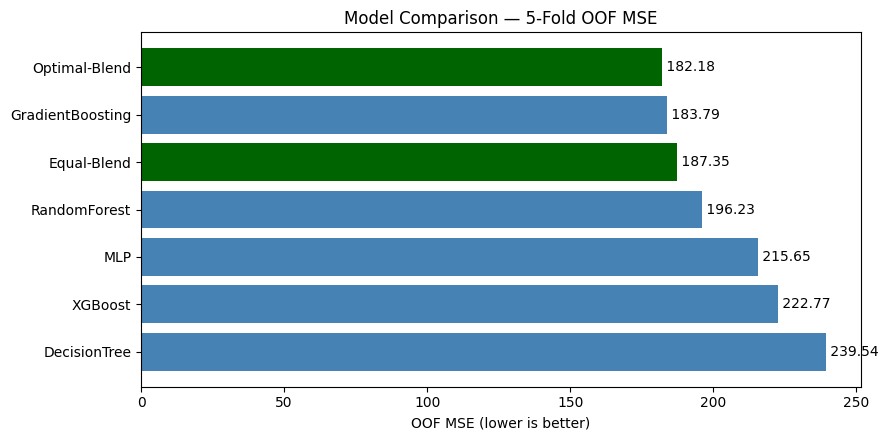

In [9]:
all_scores = {m: mean_squared_error(y, np.clip(oofs[m], 0, 92)) for m in model_names}
all_scores['Equal-Blend'] = mse_equal
all_scores['Optimal-Blend'] = mse_opt
scores = pd.Series(all_scores).sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['darkgreen' if 'Blend' in s else 'steelblue' for s in scores.index]
ax.barh(scores.index, scores.values, color=colors)
for i, v in enumerate(scores.values):
    ax.text(v, i, f' {v:.2f}', va='center')
ax.set_xlabel('OOF MSE (lower is better)')
ax.set_title('Model Comparison — 5-Fold OOF MSE')
ax.invert_yaxis()
plt.tight_layout(); plt.savefig(OUT_DIR / 'final_comparison.png', dpi=120); plt.show()

## Summary
- All models built strictly within the COMP 468 module list (DecisionTree, RandomForest, GradientBoosting, XGBoost, MLP).
- Five 5-fold OOFs combined with weighted averaging (SLSQP optimisation).
- Final submission `submission_blend.csv` is ready for Kaggle.
- AGU acknowledgment is in the README and should be repeated in the Kaggle notebook description and in the IEEE paper.

**Next:** upload `submission_blend.csv` to Kaggle, record the Public LB score, and use it as the centrepiece of the IEEE final-project paper.